In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "6"

In [2]:
from pathlib import Path
from functools import partial
from itertools import product

import datasets as hfds
import torch
import numpy as np
import pandas as pd
from torch.utils import flop_counter
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt

import flat_mae.transforms as flat_transforms
import flat_mae.data as flat_data
import flat_mae.models_mae as models_mae
import flat_mae.masking as flat_masking

In [3]:
torch.backends.cudnn.benchmark = True

In [4]:
plt.style.use("../clane.v2.mplstyle")
PLOTW = 3.25  # 6.75 two column width, 0.25 pad
plt.rcParams["figure.dpi"] = 300

In [5]:
# get some data
# just for computing training flops per batch
# note, hardcoded params from the config
dataset_root = "s3://medarc/fmri-datasets/eval"
space = "flat"
img_size = (224, 560)
patch_size = 16
t_patch_size = 4
masking = "tube"
mask_ratio = 0.9
batch_size = 32

transform = flat_transforms.make_transform(space)
dataset = hfds.load_dataset(
    "arrow",
    data_files=f"{dataset_root}/hcpya-clips.{space}.arrow/test/*.arrow",
    split="train",
)
dataset = flat_data.HFDataset(dataset, transform)
mask_fn = flat_masking.create_masking(
    name=masking,
    mask_ratio=mask_ratio,
    img_size=img_size,
    patch_size=patch_size,
    t_patch_size=t_patch_size,
)
collate_fn = partial(flat_masking.mask_collate, mask_fn=mask_fn)
loader = DataLoader(
    dataset,
    batch_size=batch_size,
    collate_fn=collate_fn,
    shuffle=False,
    num_workers=8,
    drop_last=False,
)

Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

In [6]:
recompute_flops = False
depths = [3, 6, 9, 12, 15]

if recompute_flops:
    device = torch.device("cuda")
    models = {}

    for depth in depths:
        ckpt_path = f"output/model_scaling/d{depth}/pretrain/checkpoint-last.pth"
        models[depth] = models_mae.MaskedAutoencoderViT.from_checkpoint(ckpt_path).to(device)

    # fwd+bwd flops per step on a single batch
    batch = next(iter(loader))
    bold = batch["bold"].to(device)
    mask = batch["mask"].to(device)
    visible_mask = batch["visible_mask"].to(device)

    flops = {}
    for depth in depths:
        model = models[depth]
        counter = flop_counter.FlopCounterMode(display=False)
        with counter:
            loss = model(
                bold,
                img_mask=mask,
                visible_mask=visible_mask,
                mask_ratio=mask_ratio,
                with_state=False,
            )
            loss.backward()
        flops[depth] = float(counter.get_total_flops())
        print(f"d{depth} {flops[depth] / 1e9:.0f}G")
    print(flops)

    num_params = {}
    for depth in depths:
        num_params[depth] = num = sum(p.numel() for p in models[depth].parameters())
        print(f"d{depth} {num / 1e6:.0f}M")
    print(num_params)
else:
    flops = {
        3: 301657542656.0,
        6: 1492878835712.0,
        9: 4198726324224.0,
        12: 9044262453248.0,
        15: 16654549667840.0,
    }
    num_params = {3: 1979584, 6: 13168384, 9: 42709184, 12: 99744256, 15: 193415872}

In [7]:
# load the full training logs for each run
tables = []
for depth in depths:
    log_path = f"output/model_scaling/d{depth}/pretrain/log.json"
    table = pd.read_json(log_path, lines=True)
    assert len(table) == 100, f"incomplete run {depth}"
    table.insert(0, "depth", depth)
    tables.append(table)

train_logs = pd.concat(tables, ignore_index=True)
print(train_logs.shape)
train_logs.head()

(500, 8)


,depth,epoch,train/lr,train/grad,train/loss,eval/hcp-train-subset/loss,eval/hcp-val/loss,eval/nsd-val/loss
0,3,0,0.000013,0.028102,0.995238,0.993662,0.993595,0.992893
1,3,1,0.000038,0.156348,0.990996,0.988904,0.987908,0.986133
2,3,2,0.000063,0.273202,0.982968,0.975894,0.976668,0.969183
3,3,3,0.000088,0.328873,0.963467,0.948390,0.948122,0.928609
4,3,4,0.000113,0.307492,0.939236,0.928840,0.927448,0.897169


In [8]:
# get the best epoch and loss for both hcp and nsd
# note we find the best epoch for each dataset separately, since they need not be the same
records = []
for depth, group in train_logs.groupby("depth"):
    hcp_idx = group["eval/hcp-val/loss"].argmin()
    hcp_loss = group.iloc[hcp_idx]["eval/hcp-val/loss"]
    nsd_idx = group["eval/nsd-val/loss"].argmin()
    nsd_loss = group.iloc[nsd_idx]["eval/nsd-val/loss"]
    record = {
        "depth": depth,
        "hcp_epoch": hcp_idx,
        "nsd_epoch": nsd_idx,
        "hcp_loss": hcp_loss,
        "nsd_loss": nsd_loss,
    }
    records.append(record)
best_losses = pd.DataFrame.from_records(records)
best_losses = best_losses.set_index("depth")
best_losses

,hcp_epoch,nsd_epoch,hcp_loss,nsd_loss
depth,,,,
3,93,94,0.855438,0.824220
6,98,92,0.833801,0.811278
9,95,53,0.827967,0.807045
12,99,58,0.827427,0.808666
15,98,60,0.826918,0.808894


In [9]:
# prop_cycle = plt.rcParams["axes.prop_cycle"]
# colors = prop_cycle.by_key()["color"]
colors = ["#0072B2", "#009E73", "#E69F00", "#D55E00", "#CC79A7", "#474747"]
print(colors)

['#0072B2', '#009E73', '#E69F00', '#D55E00', '#CC79A7', '#474747']


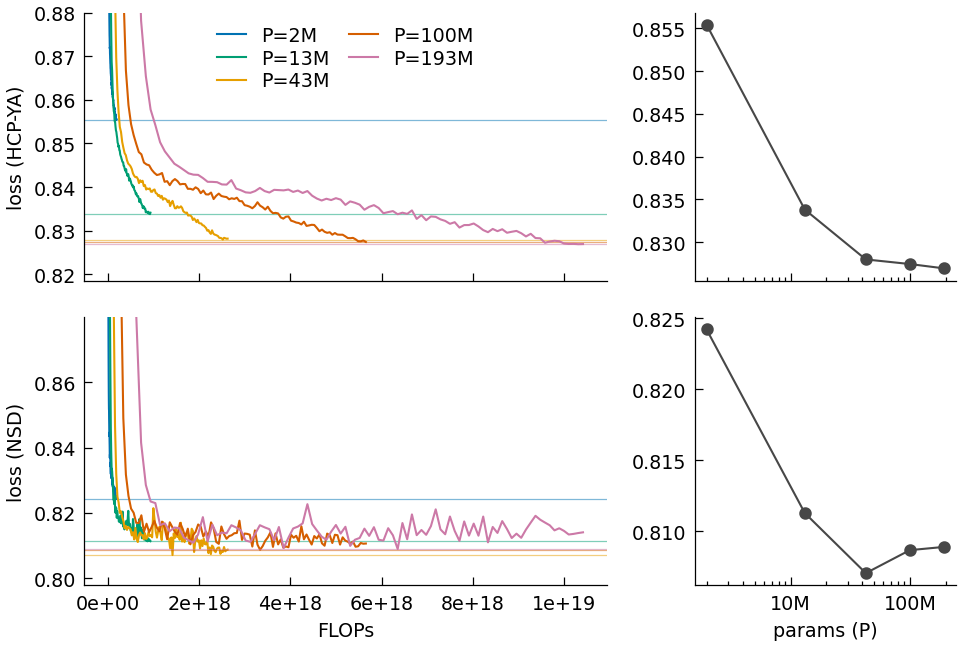

In [10]:
# 2 x 2 plot
# left col: test loss curves (aspect 2)
# right col: best loss as a function of params

f = plt.figure(figsize=(PLOTW, 2.2), constrained_layout=True)
gs = f.add_gridspec(2, 3)

ax1 = f.add_subplot(gs[0, :2])
ax2 = f.add_subplot(gs[1, :2], sharex=ax1)
ax3 = f.add_subplot(gs[0, 2])
ax4 = f.add_subplot(gs[1, 2], sharex=ax3)

# plot test loss with x axis in flops
x_steps = np.arange(1, 101) * 6250

for ii, (depth, group) in enumerate(train_logs.groupby("depth")):
    x_flops = flops[depth] * x_steps
    ax1.plot(
        x_flops,
        group["eval/hcp-val/loss"],
        lw=0.5,
        color=colors[ii],
        label=f"P={num_params[depth] / 1e6:.0f}M",
    )
    ax1.axhline(group["eval/hcp-val/loss"].min(), color=colors[ii], lw=0.3, alpha=0.5)
    ax2.plot(
        x_flops,
        group["eval/nsd-val/loss"],
        lw=0.5,
        color=colors[ii],
    )
    ax2.axhline(group["eval/nsd-val/loss"].min(), color=colors[ii], lw=0.3, alpha=0.5)

ax1.tick_params("x", labelbottom=False)
ax2.xaxis.set_major_formatter(lambda x, pos: f"{x:.0e}")
ax1.set_ylabel("loss (HCP-YA)", fontsize="small")
ax2.set_ylabel("loss (NSD)", fontsize="small")
ax2.set_xlabel("FLOPs", fontsize="small")
ax1.set_ylim(None, 0.88)
ax2.set_ylim(None, 0.88)
ax2.set_yticks([0.8, 0.82, 0.84, 0.86])
# ax1.legend(loc="upper right", ncol=1, fontsize="small")
ax1.legend(loc="upper center", ncol=2, fontsize="small")

# plot best loss as a function of params
x = np.array([num_params[depth] for depth in depths])

y = best_losses["hcp_loss"]
ax3.plot(x, y, "o-", ms=2, color=colors[-1])
ax3.tick_params("x", labelbottom=False)

y = best_losses["nsd_loss"]
ax4.plot(x, y, "o-", ms=2, color=colors[-1])

ax3.set_xscale("log")
ax4.xaxis.set_major_formatter(lambda x, pos: f"{x / 1e6:.0f}M")
ax4.set_xlabel("params (P)", fontsize="small")

f.savefig("results/model_scaling.pdf")

In [11]:
# downstream analysis

tables = []
for depth in depths:
    if depth == 12:
        out_dirs = [
            Path("../input_space_v2/output/input_space_v2/flat_lr1e-3_1"),
            Path("../input_space_v2/output/input_space_v2/flat_lr1e-3_2"),
        ]
    else:
        out_dirs = [
            Path(f"output/model_scaling/d{depth}"),
            Path(f"output/model_scaling/d{depth}_2"),
        ]
    for ii, out_dir in enumerate(out_dirs):
        paths = sorted(out_dir.rglob("eval_table.csv"))
        table = pd.concat((pd.read_csv(p) for p in paths), ignore_index=True)
        table.insert(0, "repeat", ii + 1)
        table.insert(0, "depth", depth)
        tables.append(table)
table = pd.concat(tables, ignore_index=True)
print(table.shape)
table.head()

(29976, 23)


,depth,repeat,model,repr,clf,dataset,epoch,lr,wd,hparam_id,...,acc,acc_std,f1,f1_std,trial,C,bacc,bacc_std,ckpt,trial_id
0,3,1,flat_mae,patch,attn,aabc_age,3.0,0.03,0.0015,42.0,...,0.712088,0.020798,0.713078,0.020783,NaN,NaN,NaN,NaN,NaN,NaN
1,3,1,flat_mae,patch,attn,aabc_age,3.0,0.03,0.0015,42.0,...,0.415094,0.067722,0.425904,0.067355,NaN,NaN,NaN,NaN,NaN,NaN
2,3,1,flat_mae,patch,attn,aabc_age,3.0,0.03,0.0015,42.0,...,0.288462,0.061584,0.286478,0.062785,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1,flat_mae,patch,attn,aabc_sex,0.0,0.01,0.0050,36.0,...,0.794055,0.018164,0.783068,0.019870,NaN,NaN,NaN,NaN,NaN,NaN
4,3,1,flat_mae,patch,attn,aabc_sex,0.0,0.01,0.0050,36.0,...,0.844828,0.048469,0.836620,0.050913,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
state_datasets = ["hcpya_task21", "nsd_cococlip"]

state_summary = (
    table.loc[(table["split"] == "test") & (table["dataset"].isin(state_datasets))]
    .dropna(axis=1, how="all")
    .pivot_table(
        values=["acc", "acc_std"], index=["depth", "repeat", "repr", "clf"], columns="dataset"
    )
    .loc[(slice(None), slice(None), "patch", "attn")]
)
state_summary

acc                   acc_std             
dataset      hcpya_task21 nsd_cococlip hcpya_task21 nsd_cococlip
depth repeat                                                    
3     1          0.961806     0.280705     0.002741     0.005220
      2          0.960913     0.272356     0.002698     0.005175
6     1          0.976786     0.285807     0.002091     0.005437
      2          0.976389     0.284601     0.002209     0.005155
9     1          0.985813     0.299443     0.001623     0.005358
      2          0.983730     0.291466     0.001761     0.005134
12    1          0.985689     0.303131     0.001581     0.005419
      2          0.985714     0.296730     0.001639     0.005344
15    1          0.990079     0.310390     0.001360     0.005610
      2          0.987302     0.288497     0.001579     0.005069

In [13]:
def sem(x):
    return x.std() / (len(x) ** 0.5)


trait_datasets = ["aabc_age", "aabc_sex"]
trait_metric = "bacc"

trait_repr = "patch"

trait_summary = (
    table.loc[
        (table["split"] == "test") & (table["dataset"].isin(trait_datasets)) & (table["trial"] > 0)
    ]
    .dropna(axis=1, how="all")
    .pivot_table(
        values=[trait_metric],
        index=["depth", "repeat", "repr", "clf"],
        columns="dataset",
        aggfunc=["mean", sem],
    )
    .loc[(slice(None), slice(None), trait_repr, "logistic")]
)
trait_summary.columns = pd.MultiIndex.from_tuples(
    [(metric, ds) for metric, ds in product(["acc", "acc_std"], trait_datasets)]
)
trait_summary

acc             acc_std          
              aabc_age  aabc_sex  aabc_age  aabc_sex
depth repeat                                        
3     1       0.455071  0.811793  0.007034  0.004926
      2       0.441000  0.812351  0.006873  0.004694
6     1       0.448020  0.843560  0.006532  0.004968
      2       0.451694  0.823451  0.007176  0.005019
9     1       0.458551  0.876345  0.007022  0.004902
      2       0.464270  0.867677  0.006826  0.004881
12    1       0.424799  0.866739  0.006250  0.004412
      2       0.457296  0.856270  0.006773  0.004498
15    1       0.483956  0.876488  0.005667  0.004421
      2       0.453294  0.877323  0.006541  0.004468

In [14]:
summary = pd.concat([state_summary, trait_summary], axis=1)
summary

acc                   acc_std                    acc  \
             hcpya_task21 nsd_cococlip hcpya_task21 nsd_cococlip  aabc_age   
depth repeat                                                                 
3     1          0.961806     0.280705     0.002741     0.005220  0.455071   
      2          0.960913     0.272356     0.002698     0.005175  0.441000   
6     1          0.976786     0.285807     0.002091     0.005437  0.448020   
      2          0.976389     0.284601     0.002209     0.005155  0.451694   
9     1          0.985813     0.299443     0.001623     0.005358  0.458551   
      2          0.983730     0.291466     0.001761     0.005134  0.464270   
12    1          0.985689     0.303131     0.001581     0.005419  0.424799   
      2          0.985714     0.296730     0.001639     0.005344  0.457296   
15    1          0.990079     0.310390     0.001360     0.005610  0.483956   
      2          0.987302     0.288497     0.001579     0.005069  0.453294   

                         acc_std            
              aabc_sex  aabc_age  aabc_sex  
depth repeat                                
3     1       0.811793  0.007034  0.004926  
      2       0.812351  0.006873  0.004694  
6     1       0.843560  0.006532  0.004968  
      2       0.823451  0.007176  0.005019  
9     1       0.876345  0.007022  0.004902  
      2       0.867677  0.006826  0.004881  
12    1       0.866739  0.006250  0.004412  
      2       0.856270  0.006773  0.004498  
15    1       0.876488  0.005667  0.004421  
      2       0.877323  0.006541  0.004468

In [15]:
DATASET_NAMES = {
    "abide_dx": "ABIDE Dx",
    "abide_age": "ABIDE Age",
    "abide_sex": "ABIDE Sex",
    "adhd200_dx": "ADHD200 Dx",
    "adhd200_sex": "ADHD200 Sex",
    "adni_ad_vs_cn": "ADNI Dx",
    "adni_sex": "ADNI Sex",
    "ppmi_dx": "PPMI Dx",
    "ppmi_sex": "PPMI Sex",
    "ppmi_age": "PPMI Age",
    "hcpya_rest1lr_gender": "HCP-YA Sex",
    "hcpya_rest1lr_age": "HCP-YA Age",
    "hcpya_rest1lr_neofacn": "HCP-YA NEO-N",
    "aabc_sex": "HCP-A Sex",
    "aabc_age": "HCP-A Age",
    "hcpya_task21": "HCP-YA Task21",
    "nsd_cococlip": "NSD COCO24",
}

In [16]:
sigmas = {
    "abide_dx": 0.009,
    "adhd200_dx": 0.0042,
    "adni_ad_vs_cn": 0.013,
    "ppmi_dx": 0.0126,
    "aabc_age": 0.0115,
    "aabc_sex": 0.0099,
    "hcpya_task21": 0.0011,
    "nsd_cococlip": 0.0101,
}

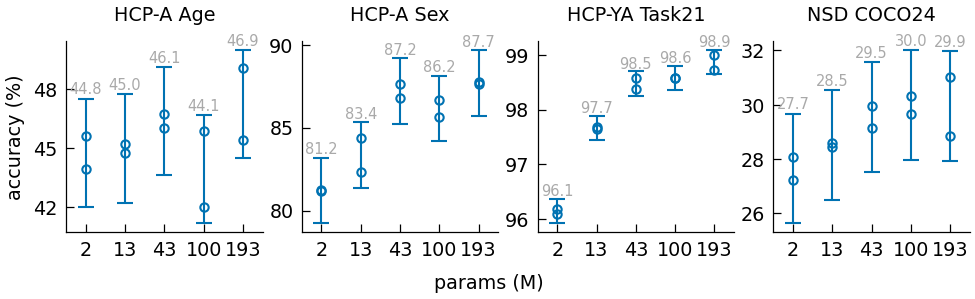

In [17]:
from matplotlib.ticker import FormatStrFormatter

datasets = ["aabc_age", "aabc_sex", "hcpya_task21", "nsd_cococlip"]

f, axs = plt.subplots(1, len(datasets), figsize=(PLOTW, 1.0))

ticklabels = [f"{par / 1e6:.0f}" for par in num_params.values()]
for ii, ds in enumerate(datasets):
    ax = axs[ii]
    plt.sca(ax)
    for jj, depth in enumerate(depths):
        subdf = summary.loc[depth]
        scores = 100 * subdf.loc[:, ("acc", ds)].values
        stds = 100 * subdf.loc[:, ("acc_std", ds)].values
        score = np.mean(scores)
        # std = np.sqrt(np.mean(stds**2))
        std = 100 * sigmas[ds]
        ax.errorbar(
            [jj],
            [score],
            yerr=[2 * std],
            color=colors[0],
            elinewidth=0.5,
            capsize=2.0,
            capthick=0.5,
        )
        ax.plot([jj, jj], scores, "o", color=colors[0], ms=2, mfc="none", mew=0.5)
        ax.text(
            jj,
            score + 1.03 * 2 * std,
            f"{score:.1f}",
            fontsize=3.5,
            color="darkgray",
            ha="center",
            va="bottom",
        )

    ax.set_title(DATASET_NAMES[ds], fontsize="small", pad=5)
    if ii == 0:
        ax.set_ylabel("accuracy (%)", fontsize="small")

    ax.set_xticks(np.arange(len(depths)), ticklabels)
    ax.set_xlim(-0.5, len(depths) - 0.5)
    # if ds == "nsd_cococlip":
    #     ax.set_yticks([26, 28, 30, 32])
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))

plt.tight_layout(pad=0.2)

f.subplots_adjust(bottom=0.23)
f.text(0.5, 0.04, "params (M)", ha="center", fontsize="small")
f.savefig("results/model_scaling_downstream.pdf")